# 3) Limpieza de Datos - Gender Classifier

**Objetivo:** Determinar cuales variables del dataset pueden ser implementadas para la construccion del modelo de clasificacion de genero, justificando cada decision. Luego, aplicar las transformaciones de limpieza necesarias para preparar los datos.

**Pregunta clave:** *De las variables que componen el problema, cuales pueden ser implementadas para la construccion del modelo? Justifique la respuesta.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)

SEED = 42
np.random.seed(SEED)

In [2]:
import os

_candidates = [
    "data/gender-classifier-DFE-791531.csv",
    "../data/gender-classifier-DFE-791531.csv",
    "/app/data/gender-classifier-DFE-791531.csv",
]
DATA_PATH = next(p for p in _candidates if os.path.exists(p))

df = pd.read_csv(DATA_PATH, encoding="latin-1")
print(f"Archivo cargado desde: {DATA_PATH}")
print(f"Dimensiones originales: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\nColumnas ({len(df.columns)}):\n{list(df.columns)}")

Archivo cargado desde: ../data/gender-classifier-DFE-791531.csv
Dimensiones originales: 20050 filas x 26 columnas

Columnas (26):
['_unit_id', '_golden', '_unit_state', '_trusted_judgments', '_last_judgment_at', 'gender', 'gender:confidence', 'profile_yn', 'profile_yn:confidence', 'created', 'description', 'fav_number', 'gender_gold', 'link_color', 'name', 'profile_yn_gold', 'profileimage', 'retweet_count', 'sidebar_color', 'text', 'tweet_coord', 'tweet_count', 'tweet_created', 'tweet_id', 'tweet_location', 'user_timezone']


## 1. Clasificacion de Variables

El dataset contiene **26 columnas**. Antes de limpiar, es fundamental clasificar cada variable segun su naturaleza y utilidad para el modelo.

### Categorias de clasificacion:
- **Variable objetivo:** La variable que queremos predecir.
- **Variables administrativas:** Metadatos de la plataforma CrowdFlower, no relacionados con el perfil del usuario.
- **Variables de perfil:** Informacion del perfil de Twitter del usuario.
- **Variables de actividad:** Metricas de comportamiento del usuario.
- **Variables de texto:** Contenido textual que requiere procesamiento NLP.
- **Variables de contexto:** Ubicacion, zona horaria, coordenadas.

In [3]:
# Panorama rapido: tipos, nulos y valores unicos por columna
resumen = pd.DataFrame({
    "Tipo": df.dtypes,
    "No Nulos": df.notnull().sum(),
    "Nulos": df.isnull().sum(),
    "% Nulos": (df.isnull().sum() / len(df) * 100).round(2),
    "Unicos": df.nunique(),
})
resumen

,Tipo,No Nulos,Nulos,% Nulos,Unicos
_unit_id,int64,20050,0,0.00,20050
_golden,bool,20050,0,0.00,2
_unit_state,str,20050,0,0.00,2
_trusted_judgments,int64,20050,0,0.00,32
_last_judgment_at,str,20000,50,0.25,283
gender,str,19953,97,0.48,4
gender:confidence,float64,20024,26,0.13,923
profile_yn,str,20050,0,0.00,2
profile_yn:confidence,float64,20050,0,0.00,267
created,str,20050,0,0.00,18699


## 2. Analisis de Cada Variable: Incluir o Excluir

A continuacion se evalua cada una de las 26 variables para determinar si debe ser **incluida** o **excluida** del modelo, con su justificacion.

### 2.1 Variables EXCLUIDAS (administrativas / sin valor predictivo)

| Variable | Tipo | Justificacion para EXCLUIR |
|---|---|---|
| `_unit_id` | int | Identificador interno de CrowdFlower. No tiene relacion con el genero del usuario. Es un ID arbitrario. |
| `_golden` | bool | Indica si la fila es un registro de control (gold standard) de CrowdFlower. Es metadata del proceso de anotacion, no del usuario. |
| `_unit_state` | str | Estado del proceso de anotacion (`finalized`). Administrativo, no describe al usuario. |
| `_trusted_judgments` | int | Numero de juicios confiables del proceso de anotacion. No es un atributo del usuario de Twitter. |
| `_last_judgment_at` | str | Fecha del ultimo juicio de anotacion. No tiene relacion con el genero. |
| `gender:confidence` | float | **Confianza de la anotacion de genero.** Si bien es numerica, incluirla causaria **data leakage** ya que esta directamente derivada de la variable objetivo. El modelo no tendria acceso a esta informacion en produccion. |
| `profile_yn` | str | Indica si el usuario tiene perfil. Casi el 100% de los registros son `yes` (19,953 de 20,050), por lo que **no aporta varianza ni poder discriminativo**. |
| `profile_yn:confidence` | float | Confianza de la anotacion de profile_yn. Mismo argumento que `gender:confidence` — metadata de anotacion. |
| `gender_gold` | str | Etiqueta gold standard de genero. **99.75% valores nulos** y es parte del proceso de control de calidad, no un atributo del usuario. |
| `profile_yn_gold` | str | Etiqueta gold standard de profile_yn. **99.75% valores nulos**, misma razon que `gender_gold`. |
| `profileimage` | str | URL de la imagen de perfil. Aunque podria usarse con modelos de vision por computador, es una **URL** (string), no la imagen en si. Requeriria descarga y procesamiento de imagenes, lo cual esta fuera del alcance de este modelo. |
| `tweet_coord` | str | Coordenadas del tweet. **99.21% valores nulos.** La cantidad de datos faltantes es demasiado alta para ser util. |
| `tweet_id` | float | Identificador unico del tweet. Es un ID numerico sin significado predictivo. |
| `tweet_created` | str | Fecha de creacion del tweet. Solo tiene **5 valores unicos** (todos del mismo dia), por lo que no aporta variabilidad. |

In [4]:
# Verificacion de las justificaciones
print("=== profile_yn - distribucion ===")
print(df["profile_yn"].value_counts())
print(f"\n=== tweet_created - valores unicos: {df['tweet_created'].nunique()} ===")
print(df["tweet_created"].value_counts())
print(f"\n=== tweet_coord - % nulos: {df['tweet_coord'].isnull().mean()*100:.2f}%")
print(f"=== gender_gold - % nulos: {df['gender_gold'].isnull().mean()*100:.2f}%")
print(f"=== profile_yn_gold - % nulos: {df['profile_yn_gold'].isnull().mean()*100:.2f}%")

=== profile_yn - distribucion ===
profile_yn
yes    19953
no        97
Name: count, dtype: int64

=== tweet_created - valores unicos: 5 ===
tweet_created
10/26/15 12:40    8076
10/26/15 13:19    5892
10/26/15 13:20    3865
10/26/15 12:39    1952
10/26/15 13:18     265
Name: count, dtype: int64

=== tweet_coord - % nulos: 99.21%
=== gender_gold - % nulos: 99.75%
=== profile_yn_gold - % nulos: 99.75%


### 2.2 Variables INCLUIDAS (con valor predictivo)

| Variable | Tipo | Categoria | Justificacion para INCLUIR |
|---|---|---|---|
| `gender` | str | **Objetivo** | Es la **variable a predecir**. Contiene las categorias `male`, `female`, `brand` y `unknown`. |
| `description` | str | Texto | La biografia del usuario es una **fuente rica de informacion textual**. Puede contener indicadores de genero como pronombres, profesiones, intereses. Se puede extraer: longitud, conteo de palabras, y features NLP. |
| `text` | str | Texto | El contenido del tweet refleja **patrones linguisticos** que pueden diferir por genero (vocabulario, tematicas, estilo). Util para features de NLP. |
| `name` | str | Perfil | El nombre de usuario frecuentemente **contiene el nombre real** del usuario, que es un fuerte indicador de genero (ej: "Maria", "David"). Se pueden extraer features como longitud o presencia de nombres comunes. |
| `fav_number` | int | Actividad | Numero de favoritos dados. Es una **metrica de engagement** que puede variar por genero, ya que diferentes grupos pueden tener diferentes niveles de actividad en la plataforma. |
| `tweet_count` | int | Actividad | Numero total de tweets. Representa la **frecuencia de publicacion** del usuario, un patron de comportamiento que puede diferir entre categorias. |
| `retweet_count` | int | Actividad | Cantidad de retweets. Mide el **comportamiento de compartir contenido**, otro patron de uso que puede tener diferencias por genero. |
| `link_color` | str | Perfil | Color hexadecimal del enlace del perfil. Las **preferencias de personalizacion visual** pueden correlacionarse con el genero. Estudios muestran que las preferencias de color varian entre grupos demograficos. |
| `sidebar_color` | str | Perfil | Color hexadecimal del sidebar. Misma logica que `link_color` — las elecciones de **diseño del perfil** pueden ser discriminativas. |
| `created` | str | Perfil | Fecha de creacion de la cuenta. Permite calcular la **antiguedad de la cuenta**, que puede correlacionarse con patrones de uso diferentes por genero. |
| `tweet_location` | str | Contexto | Ubicacion reportada del tweet. Aunque tiene **37.33% de nulos**, la ubicacion puede ser util ya que los patrones de genero varian por region. Se puede imputar o usar como feature opcional. |
| `user_timezone` | str | Contexto | Zona horaria del usuario. Tiene **38.89% de nulos**, pero proporciona informacion de **geolocalizacion indirecta** que puede complementar el modelo. |

In [5]:
# Definir las columnas a incluir y excluir
cols_excluir = [
    "_unit_id", "_golden", "_unit_state", "_trusted_judgments",
    "_last_judgment_at", "gender:confidence", "profile_yn",
    "profile_yn:confidence", "gender_gold", "profile_yn_gold",
    "profileimage", "tweet_coord", "tweet_id", "tweet_created",
]

cols_incluir = [
    "gender",         # variable objetivo
    "description",    # texto - biografia
    "text",           # texto - tweet
    "name",           # perfil - nombre de usuario
    "fav_number",     # actividad
    "tweet_count",    # actividad
    "retweet_count",  # actividad
    "link_color",     # perfil - personalizacion
    "sidebar_color",  # perfil - personalizacion
    "created",        # perfil - fecha de creacion
    "tweet_location", # contexto
    "user_timezone",  # contexto
]

print(f"Variables excluidas: {len(cols_excluir)}")
print(f"Variables incluidas: {len(cols_incluir)}")
print(f"Total: {len(cols_excluir) + len(cols_incluir)} (de {len(df.columns)} originales)")

Variables excluidas: 14
Variables incluidas: 12
Total: 26 (de 26 originales)


### 2.3 Resumen Visual de la Seleccion

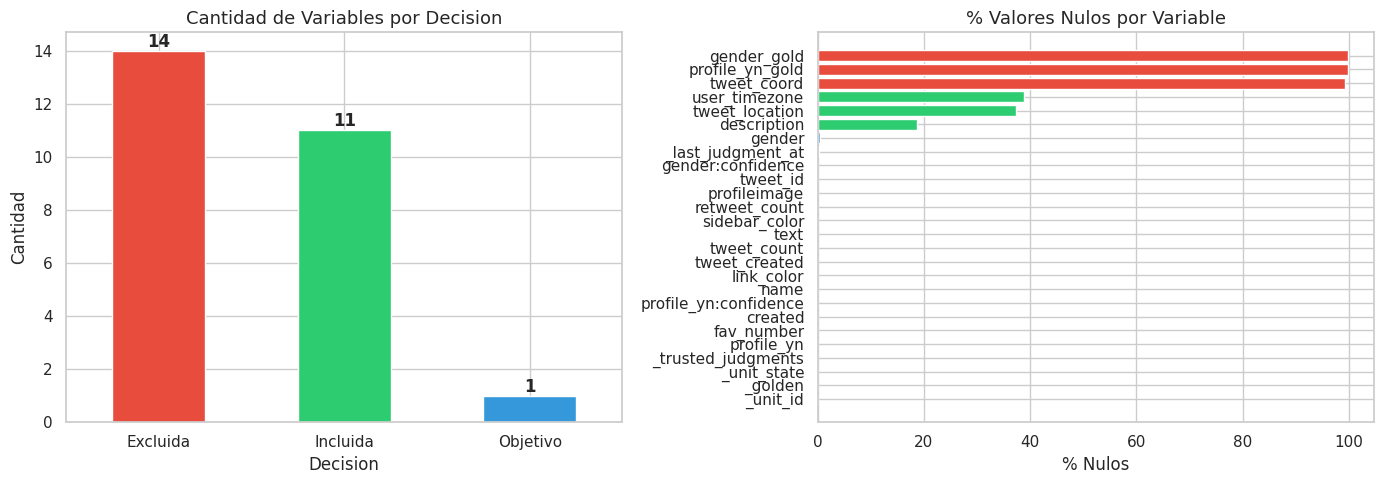

,Variable,Decision,% Nulos,Unicos
0,_unit_id,Excluida,0.00,20050
1,_golden,Excluida,0.00,2
2,_unit_state,Excluida,0.00,2
3,_trusted_judgments,Excluida,0.00,32
4,_last_judgment_at,Excluida,0.25,283
5,gender,Objetivo,0.48,4
6,gender:confidence,Excluida,0.13,923
7,profile_yn,Excluida,0.00,2
8,profile_yn:confidence,Excluida,0.00,267
9,created,Incluida,0.00,18699


In [6]:
# Tabla resumen de la decision por variable
decisiones = []
for col in df.columns:
    if col == "gender":
        cat = "Objetivo"
    elif col in cols_excluir:
        cat = "Excluida"
    else:
        cat = "Incluida"
    decisiones.append({
        "Variable": col,
        "Decision": cat,
        "% Nulos": round(df[col].isnull().mean() * 100, 2),
        "Unicos": df[col].nunique(),
    })

df_decisiones = pd.DataFrame(decisiones)

# Visualizar la proporcion de decision
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo de decisiones
counts = df_decisiones["Decision"].value_counts()
colors = {"Excluida": "#e74c3c", "Incluida": "#2ecc71", "Objetivo": "#3498db"}
counts.plot(kind="bar", color=[colors[x] for x in counts.index], ax=axes[0])
axes[0].set_title("Cantidad de Variables por Decision", fontsize=13)
axes[0].set_ylabel("Cantidad")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}", 
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha="center", va="bottom", fontsize=12, fontweight="bold")

# % Nulos por variable, coloreado por decision
df_sorted = df_decisiones.sort_values("% Nulos", ascending=True)
bar_colors = [colors[d] for d in df_sorted["Decision"]]
axes[1].barh(df_sorted["Variable"], df_sorted["% Nulos"], color=bar_colors)
axes[1].set_title("% Valores Nulos por Variable", fontsize=13)
axes[1].set_xlabel("% Nulos")

plt.tight_layout()
plt.show()

df_decisiones

## 3. Aplicar la Seleccion de Variables

Se eliminan las columnas excluidas y se trabaja unicamente con las variables seleccionadas.

In [7]:
df_clean = df[cols_incluir].copy()
print(f"Dimensiones despues de seleccion: {df_clean.shape}")
df_clean.head()

Dimensiones despues de seleccion: (20050, 12)


,gender,description,text,name,fav_number,tweet_count,retweet_count,link_color,sidebar_color,created,tweet_location,user_timezone
0,male,i sing my own rhythm.,Robbie E Responds To Critics After Win Against...,sheezy0,0,110964,0,08C2C2,FFFFFF,12/5/13 1:48,main; @Kan1shk3,Chennai
1,male,I'm the author of novels filled with family dr...,ÛÏIt felt like they were my friends and I was...,DavdBurnett,68,7471,0,0084B4,C0DEED,10/1/12 13:51,NaN,Eastern Time (US & Canada)
2,male,louis whining and squealing and all,i absolutely adore when louis starts the songs...,lwtprettylaugh,7696,5617,1,ABB8C2,C0DEED,11/28/14 11:30,clcncl,Belgrade
3,male,"Mobile guy. 49ers, Shazam, Google, Kleiner Pe...",Hi @JordanSpieth - Looking at the url - do you...,douggarland,202,1693,0,0084B4,C0DEED,6/11/09 22:39,"Palo Alto, CA",Pacific Time (US & Canada)
4,female,Ricky Wilson The Best FRONTMAN/Kaiser Chiefs T...,Watching Neighbours on Sky+ catching up with t...,WilfordGemma,37318,31462,0,3B94D9,0,4/16/14 13:23,NaN,NaN


## 4. Limpieza de la Variable Objetivo (`gender`)

In [8]:
print("=== Distribucion original de gender ===")
print(df_clean["gender"].value_counts(dropna=False))
print(f"\nRegistros nulos en gender: {df_clean['gender'].isnull().sum()}")

=== Distribucion original de gender ===
gender
female     6700
male       6194
brand      5942
unknown    1117
NaN          97
Name: count, dtype: int64

Registros nulos en gender: 97


In [9]:
# Eliminar filas sin valor en la variable objetivo (no se pueden usar para entrenar)
n_antes = len(df_clean)
df_clean = df_clean.dropna(subset=["gender"])
print(f"Filas eliminadas por gender nulo: {n_antes - len(df_clean)}")
print(f"Dimensiones actuales: {df_clean.shape}")

Filas eliminadas por gender nulo: 97
Dimensiones actuales: (19953, 12)


In [10]:
# Eliminar la categoria 'unknown' ya que no aporta informacion util para el entrenamiento
n_antes = len(df_clean)
df_clean = df_clean[df_clean["gender"] != "unknown"].copy()
print(f"Filas eliminadas por gender='unknown': {n_antes - len(df_clean)}")
print(f"\n=== Distribucion final de gender ===")
print(df_clean["gender"].value_counts())
print(f"\nDimensiones actuales: {df_clean.shape}")

Filas eliminadas por gender='unknown': 1117

=== Distribucion final de gender ===
gender
female    6700
male      6194
brand     5942
Name: count, dtype: int64

Dimensiones actuales: (18836, 12)


## 5. Limpieza de Variables de Texto

In [11]:
# Estado de nulos en variables de texto
text_cols = ["description", "text", "name"]
for col in text_cols:
    nulos = df_clean[col].isnull().sum()
    pct = nulos / len(df_clean) * 100
    print(f"{col}: {nulos} nulos ({pct:.2f}%)")

description: 3314 nulos (17.59%)
text: 0 nulos (0.00%)
name: 0 nulos (0.00%)


In [12]:
# Imputar description nula con cadena vacia (no todos los usuarios escriben biografia)
df_clean["description"] = df_clean["description"].fillna("")

# Limpiar espacios extra y caracteres especiales en textos
for col in text_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# Crear features derivadas de texto
df_clean["desc_length"] = df_clean["description"].str.len()
df_clean["desc_word_count"] = df_clean["description"].str.split().str.len().fillna(0).astype(int)
df_clean["text_length"] = df_clean["text"].str.len()
df_clean["text_word_count"] = df_clean["text"].str.split().str.len().fillna(0).astype(int)
df_clean["name_length"] = df_clean["name"].str.len()

print("Features de texto creadas:")
df_clean[["desc_length", "desc_word_count", "text_length", "text_word_count", "name_length"]].describe().round(1)

Features de texto creadas:


,desc_length,desc_word_count,text_length,text_word_count,name_length
count,18836.0,18836.0,18836.0,18836.0,18836.0
mean,71.0,10.9,98.1,15.6,11.1
std,56.6,8.8,33.8,6.0,2.6
min,0.0,0.0,6.0,1.0,2.0
25%,19.0,3.0,69.0,11.0,9.0
50%,62.0,10.0,102.0,15.0,11.0
75%,124.0,18.0,130.0,20.0,13.0
max,465.0,48.0,425.0,37.0,15.0


## 6. Limpieza de Variables Numericas

In [13]:
num_cols = ["fav_number", "tweet_count", "retweet_count"]

print("=== Estadisticas de variables numericas ===")
print(df_clean[num_cols].describe().round(2))
print(f"\n=== Nulos ===")
print(df_clean[num_cols].isnull().sum())

=== Estadisticas de variables numericas ===
       fav_number  tweet_count  retweet_count
count    18836.00     18836.00       18836.00
mean      4413.46     39135.70           0.08
std      12468.53    119130.64           2.73
min          0.00         1.00           0.00
25%         13.00      2399.75           0.00
50%        482.50     11312.50           0.00
75%       3375.50     39793.50           0.00
max     341621.00   2680199.00         330.00

=== Nulos ===
fav_number       0
tweet_count      0
retweet_count    0
dtype: int64


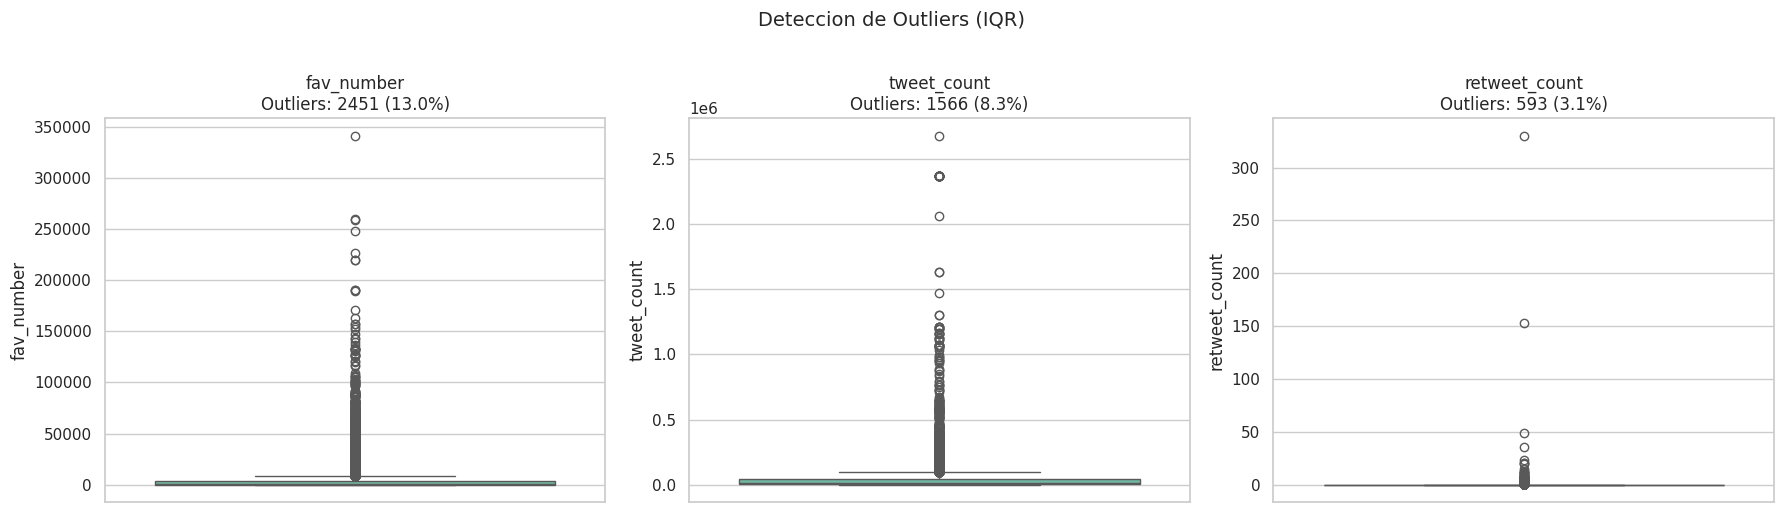

In [14]:
# Deteccion de outliers usando IQR
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    pct = outliers / len(df_clean) * 100
    
    sns.boxplot(data=df_clean, y=col, ax=axes[i])
    axes[i].set_title(f"{col}\nOutliers: {outliers} ({pct:.1f}%)", fontsize=12)

plt.suptitle("Deteccion de Outliers (IQR)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

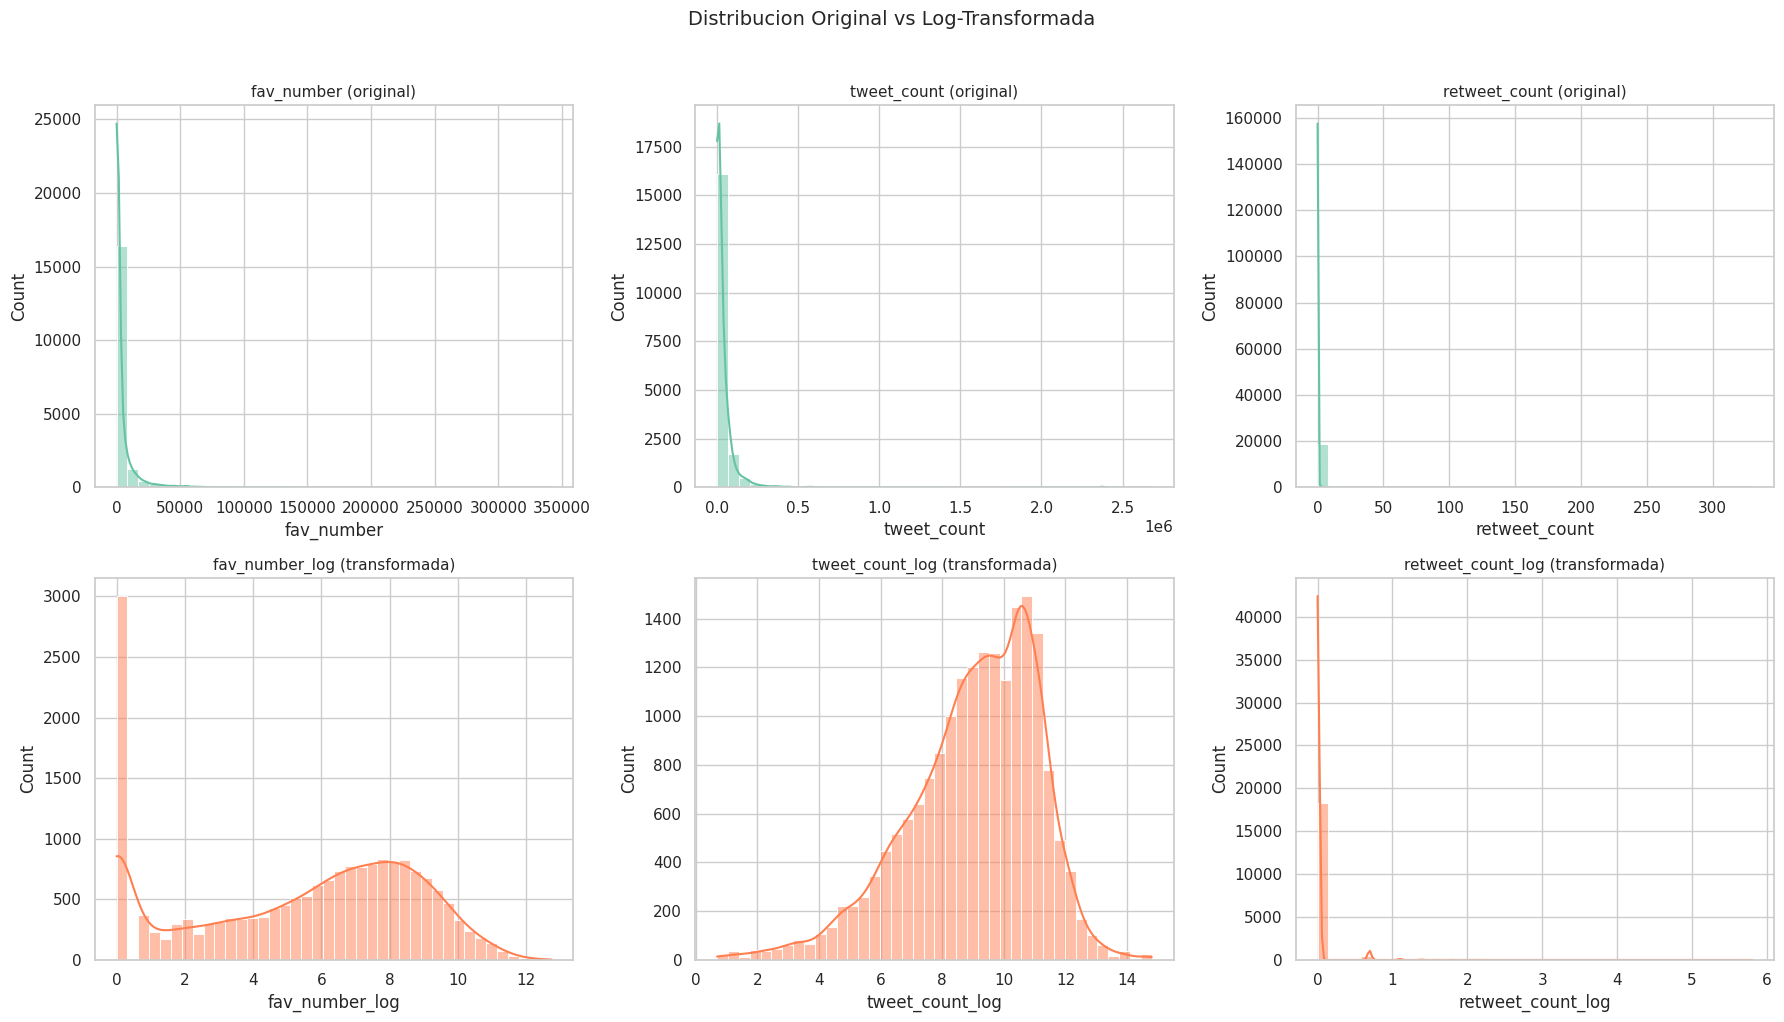

In [15]:
# Aplicar transformacion logaritmica para reducir asimetria (log1p para manejar ceros)
for col in num_cols:
    df_clean[f"{col}_log"] = np.log1p(df_clean[col])

# Comparar distribucion original vs log-transformada
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(num_cols):
    sns.histplot(df_clean[col], kde=True, ax=axes[0, i], bins=40)
    axes[0, i].set_title(f"{col} (original)", fontsize=11)
    
    sns.histplot(df_clean[f"{col}_log"], kde=True, ax=axes[1, i], bins=40, color="coral")
    axes[1, i].set_title(f"{col}_log (transformada)", fontsize=11)

plt.suptitle("Distribucion Original vs Log-Transformada", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Limpieza de Variables de Color

In [16]:
color_cols = ["link_color", "sidebar_color"]

for col in color_cols:
    print(f"\n=== {col} ===")
    print(f"Valores unicos: {df_clean[col].nunique()}")
    print(f"Nulos: {df_clean[col].isnull().sum()}")
    print(f"Top 5 valores:")
    print(df_clean[col].value_counts().head())


=== link_color ===
Valores unicos: 2882
Nulos: 0
Top 5 valores:
link_color
0084B4    9183
3B94D9     611
9999       575
DD2E44     477
9266CC     453
Name: count, dtype: int64

=== sidebar_color ===
Valores unicos: 545
Nulos: 0
Top 5 valores:
sidebar_color
C0DEED    8409
0         3789
FFFFFF    3630
EEEEEE     678
181A1E     292
Name: count, dtype: int64


In [17]:
def hex_to_rgb(hex_str):
    """Convierte un string hexadecimal a componentes R, G, B normalizados (0-1)."""
    try:
        hex_str = str(hex_str).strip().lstrip("#")
        if len(hex_str) == 3:
            hex_str = "".join(c * 2 for c in hex_str)
        if len(hex_str) != 6:
            return np.nan, np.nan, np.nan
        r = int(hex_str[0:2], 16) / 255.0
        g = int(hex_str[2:4], 16) / 255.0
        b = int(hex_str[4:6], 16) / 255.0
        return r, g, b
    except (ValueError, TypeError):
        return np.nan, np.nan, np.nan

# Extraer componentes RGB de los colores
for col in color_cols:
    rgb = df_clean[col].apply(hex_to_rgb)
    df_clean[f"{col}_r"] = rgb.apply(lambda x: x[0])
    df_clean[f"{col}_g"] = rgb.apply(lambda x: x[1])
    df_clean[f"{col}_b"] = rgb.apply(lambda x: x[2])

print("Componentes RGB extraidos:")
rgb_cols = [c for c in df_clean.columns if c.endswith(("_r", "_g", "_b"))]
df_clean[rgb_cols].describe().round(3)

Componentes RGB extraidos:


,link_color_r,link_color_g,link_color_b,sidebar_color_r,sidebar_color_g,sidebar_color_b
count,17438.000,17438.000,17438.000,15004.000,15004.000,15004.000
mean,0.248,0.474,0.618,0.791,0.863,0.895
std,0.347,0.193,0.240,0.185,0.173,0.181
min,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.515,0.667,0.753,0.871,0.929
50%,0.000,0.518,0.706,0.753,0.871,0.929
75%,0.569,0.518,0.706,0.973,0.942,0.969
max,1.000,1.000,1.000,1.000,1.000,1.000


## 8. Limpieza de Variables de Contexto

In [18]:
# Estado de nulos en variables de contexto
context_cols = ["tweet_location", "user_timezone", "created"]
for col in context_cols:
    nulos = df_clean[col].isnull().sum()
    pct = nulos / len(df_clean) * 100
    print(f"{col}: {nulos} nulos ({pct:.2f}%), {df_clean[col].nunique()} valores unicos")

tweet_location: 6842 nulos (36.32%), 7537 valores unicos
user_timezone: 7183 nulos (38.13%), 153 valores unicos
created: 0 nulos (0.00%), 17619 valores unicos


In [19]:
# Imputar nulos de ubicacion y timezone con "unknown"
df_clean["tweet_location"] = df_clean["tweet_location"].fillna("unknown")
df_clean["user_timezone"] = df_clean["user_timezone"].fillna("unknown")

# Convertir 'created' a datetime y extraer features temporales
df_clean["created_dt"] = pd.to_datetime(df_clean["created"], format="mixed", errors="coerce")
df_clean["account_age_days"] = (pd.Timestamp("2015-10-26") - df_clean["created_dt"]).dt.days
df_clean["created_year"] = df_clean["created_dt"].dt.year
df_clean["created_month"] = df_clean["created_dt"].dt.month

print("=== Features temporales ===")
print(df_clean[["account_age_days", "created_year", "created_month"]].describe().round(1))
print(f"\nNulos en account_age_days: {df_clean['account_age_days'].isnull().sum()}")

=== Features temporales ===
       account_age_days  created_year  created_month
count           18836.0       18836.0        18836.0
mean             1158.0        2012.2            6.3
std               792.5           2.2            3.3
min                -1.0        2006.0            1.0
25%               458.0        2010.0            3.8
50%              1099.0        2012.0            6.0
75%              1774.0        2014.0            9.0
max              3368.0        2015.0           12.0

Nulos en account_age_days: 0


## 9. Verificacion Final

In [20]:
# Estado final de nulos
nulos_final = df_clean.isnull().sum()
nulos_final = nulos_final[nulos_final > 0]

if len(nulos_final) == 0:
    print("No hay columnas con valores nulos en las features principales.")
else:
    print("Columnas con nulos restantes:")
    print(nulos_final)

# Imputar nulos restantes en features numericas derivadas
num_derived = df_clean.select_dtypes(include=[np.number]).columns
for col in num_derived:
    if df_clean[col].isnull().any():
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f"  -> {col}: imputado con mediana ({median_val:.1f})")

Columnas con nulos restantes:
link_color_r       1398
link_color_g       1398
link_color_b       1398
sidebar_color_r    3832
sidebar_color_g    3832
sidebar_color_b    3832
dtype: int64
  -> link_color_r: imputado con mediana (0.0)
  -> link_color_g: imputado con mediana (0.5)
  -> link_color_b: imputado con mediana (0.7)
  -> sidebar_color_r: imputado con mediana (0.8)
  -> sidebar_color_g: imputado con mediana (0.9)
  -> sidebar_color_b: imputado con mediana (0.9)


In [21]:
# Resumen final del dataset limpio
print(f"Dimensiones finales: {df_clean.shape}")
print(f"\n=== Columnas del dataset limpio ({len(df_clean.columns)}) ===")
for i, col in enumerate(df_clean.columns, 1):
    dtype = df_clean[col].dtype
    print(f"  {i:2d}. {col:25s} ({dtype})")

print(f"\n=== Variable objetivo ===")
print(df_clean["gender"].value_counts())

Dimensiones finales: (18836, 30)

=== Columnas del dataset limpio (30) ===
   1. gender                    (str)
   2. description               (str)
   3. text                      (str)
   4. name                      (str)
   5. fav_number                (int64)
   6. tweet_count               (int64)
   7. retweet_count             (int64)
   8. link_color                (str)
   9. sidebar_color             (str)
  10. created                   (str)
  11. tweet_location            (str)
  12. user_timezone             (str)
  13. desc_length               (int64)
  14. desc_word_count           (int64)
  15. text_length               (int64)
  16. text_word_count           (int64)
  17. name_length               (int64)
  18. fav_number_log            (float64)
  19. tweet_count_log           (float64)
  20. retweet_count_log         (float64)
  21. link_color_r              (float64)
  22. link_color_g              (float64)
  23. link_color_b              (float64)
  24. sideb

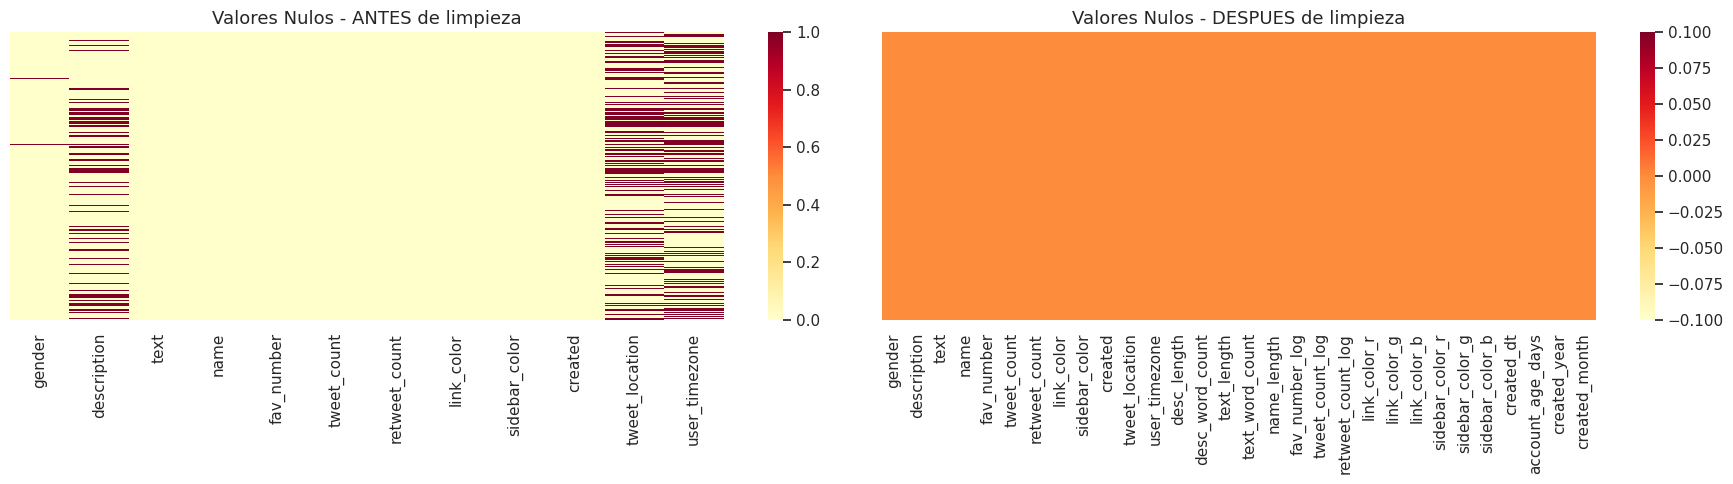

In [22]:
# Mapa de calor de nulos final
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Antes (dataset original)
sns.heatmap(df[cols_incluir].isnull(), cbar=True, yticklabels=False, cmap="YlOrRd", ax=axes[0])
axes[0].set_title("Valores Nulos - ANTES de limpieza", fontsize=13)

# Despues (dataset limpio)
sns.heatmap(df_clean.isnull(), cbar=True, yticklabels=False, cmap="YlOrRd", ax=axes[1])
axes[1].set_title("Valores Nulos - DESPUES de limpieza", fontsize=13)

plt.tight_layout()
plt.show()

In [23]:
# Guardar dataset limpio
_out_candidates = [
    "data/gender-classifier-clean.csv",
    "../data/gender-classifier-clean.csv",
    "/app/data/gender-classifier-clean.csv",
]
OUT_PATH = next(p for p in _out_candidates if os.path.exists(os.path.dirname(p)))

# Seleccionar solo las columnas finales para el modelo (excluir intermedias)
cols_modelo = [
    "gender",
    # Texto (originales para NLP posterior)
    "description", "text", "name",
    # Features numericas de texto
    "desc_length", "desc_word_count", "text_length", "text_word_count", "name_length",
    # Actividad
    "fav_number", "tweet_count", "retweet_count",
    "fav_number_log", "tweet_count_log", "retweet_count_log",
    # Colores (RGB)
    "link_color_r", "link_color_g", "link_color_b",
    "sidebar_color_r", "sidebar_color_g", "sidebar_color_b",
    # Contexto
    "tweet_location", "user_timezone",
    "account_age_days", "created_year", "created_month",
]

df_export = df_clean[cols_modelo].copy()
df_export.to_csv(OUT_PATH, index=False)
print(f"Dataset limpio guardado en: {OUT_PATH}")
print(f"Dimensiones: {df_export.shape}")

Dataset limpio guardado en: ../data/gender-classifier-clean.csv
Dimensiones: (18836, 26)


## 10. Conclusiones

### Variables seleccionadas para el modelo (12 originales → 25 features)

| Categoria | Variables originales | Features generadas |
|---|---|---|
| **Objetivo** | `gender` (3 clases: male, female, brand) | 1 |
| **Texto** | `description`, `text`, `name` | 5 numericas (longitud, conteo de palabras) + texto crudo para NLP |
| **Actividad** | `fav_number`, `tweet_count`, `retweet_count` | 6 (originales + log-transformadas) |
| **Perfil visual** | `link_color`, `sidebar_color` | 6 (componentes R, G, B) |
| **Contexto** | `created`, `tweet_location`, `user_timezone` | 3 temporales + 2 categoricas |

### Variables excluidas (14 de 26) — Justificacion resumida

1. **Administrativas** (`_unit_id`, `_golden`, `_unit_state`, `_trusted_judgments`, `_last_judgment_at`): Metadatos de CrowdFlower sin relacion con el usuario.
2. **Data leakage** (`gender:confidence`, `profile_yn:confidence`): Derivadas directamente de la variable objetivo.
3. **Sin varianza** (`profile_yn`): 99.5% del mismo valor.
4. **Exceso de nulos** (`gender_gold`, `profile_yn_gold`, `tweet_coord`): Mas del 99% nulos.
5. **Sin valor predictivo** (`tweet_id`, `tweet_created`, `profileimage`): Identificadores o URLs sin informacion discriminativa directa.

### Transformaciones aplicadas
- Eliminacion de registros con `gender` nulo o `unknown`.
- Imputacion de `description` nula con cadena vacia.
- Imputacion de `tweet_location` y `user_timezone` nulos con `"unknown"`.
- Transformacion logaritmica (`log1p`) en variables de actividad para reducir asimetria.
- Extraccion de componentes RGB de colores hexadecimales.
- Extraccion de features temporales de la fecha de creacion de cuenta.